# Case 2 - Unsupervised Learning
Welcome to the demonstration notebook where we'll go over all of the Unsupervised learning functions in the **pylenm** package!<br>
Let’s get started!


# Notebook roadmap

This demo is organized into short sections so you can follow it top-to-bottom.

- Inspection and pre-processing functions
- Correlation analysis functions
- PCA functions
- Clustering functions

> Tip: In jupyter notebook environment, you can turn on the **Table of Contents** for easier navigation. (View -> Table of Contents)


## Setup
Make sure to install pylenm from https://pypi.org/project/pylenm/ by running `pip install pylenm` in your environment terminal. Once completed, you should be able to import the package. Note: to update to the latest version of pylenm run: `pip install pylenm --upgrade`

**Note**: To make sure all dependencies (including geospatial libraries such as rasterio and pyproj) are properly installed, it is recommended to first create the environment using the provided [**pylenm_env.yml**](https://github.com/hkzhao7/pylenm/tree/main/pylenm_env.yml) file, then run the demo notebooks in the created environment.

In [1]:
# Import our packages
# import pylenm
# from pylenm import PylenmDataFactory
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('../')
from pylenm import pylenm
from pylenm.pylenm import PylenmDataFactory

pd.set_option('display.max_rows', 100) # Display a custom number of rows for dataframe

We can verify the package version by typing: `pylenm_df.__version__`

In [2]:
pylenm.__version__

'0.2.2'

In [2]:
# --- Option A (default): load demo data locally ---
# If you cloned the repo, the demo data is under: notebooks/data/
url_1 = 'data/farea_data_thru_2015q3_reduced_demo.csv'
url_2 = 'data/farea_station_construction_data.csv'

# # --- Option B: load demo data directly from GitHub (no local repo needed) ---
# # Useful for running notebooks on Google Colab or when you don't have the repo cloned.
# raw_base = "https://raw.githubusercontent.com/hkzhao7/pylenm/main/notebooks/data/"
# url_1 = raw_base + "farea_data_thru_2015q3_reduced_demo.csv"
# url_2 = raw_base + "farea_station_construction_data.csv"

concentration_data = pd.read_csv(url_1)
construction_data = pd.read_csv(url_2)

# Create instance
pylenm_df = PylenmDataFactory(concentration_data) # Save concentration data
pylenm_df.simplify_data(inplace=True)
pylenm_df.setConstructionData(construction_data) # Save construction data

Successfully imported the data!

Successfully imported the construction data!



In [13]:
pylenm_df.data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86211 entries, 0 to 86210
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   COLLECTION_DATE  86211 non-null  datetime64[ns]
 1   STATION_ID       86211 non-null  object        
 2   ANALYTE_NAME     86211 non-null  object        
 3   RESULT           85928 non-null  float64       
 4   RESULT_UNITS     86210 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 3.3+ MB


# Inspection and pre-processing functions

 The `getCleanData()` function is a preprocessing tool for restructuring the original concentration dataset into a more analysis-friendly structure.
 <br>Let's take a closer look at the function:

In [3]:
# We'll save a list of the analytes we want to look at and pass it to the functions below
analytes = ['TRITIUM','SPECIFIC CONDUCTANCE','PH','URANIUM-238','DEPTH_TO_WATER']
pylenm_df.getCleanData(analytes)

ANALYTE_NAME    DEPTH_TO_WATER                                            \
STATION_ID            FBI-014D FBI-015D FBI-017D FEX-004 FIB-001 FIB-008   
COLLECTION_DATE                                                            
1990-01-01                 NaN      NaN      NaN     NaN     NaN     NaN   
1990-01-02                 NaN      NaN      NaN     NaN     NaN     NaN   
1990-01-03                 NaN      NaN      NaN     NaN     NaN     NaN   
1990-01-06                 NaN      NaN      NaN     NaN     NaN     NaN   
1990-01-07                 NaN      NaN      NaN     NaN     NaN     NaN   
...                        ...      ...      ...     ...     ...     ...   
2015-09-10                 NaN      NaN      NaN     NaN     NaN     NaN   
2015-09-21                 NaN      NaN      NaN     NaN     NaN     NaN   
2015-09-22                 NaN      NaN      NaN     NaN     NaN     NaN   
2015-09-23                 NaN      NaN      NaN     NaN     NaN     NaN   
2015-09-24                17.4     15.4    25.16     NaN     NaN     NaN   

ANALYTE_NAME                                         ... URANIUM-238           \
STATION_ID      FOB-001D FOB-002C FOB-002D FOB-013D  ...    FSP-002B FSP-002C   
COLLECTION_DATE                                      ...                        
1990-01-01           NaN      NaN      NaN      NaN  ...         NaN      NaN   
1990-01-02           NaN      NaN      NaN      NaN  ...         NaN      NaN   
1990-01-03           NaN      NaN      NaN      NaN  ...         NaN      NaN   
1990-01-06           NaN      NaN      NaN      NaN  ...         NaN      NaN   
1990-01-07           NaN      NaN      NaN      NaN  ...         NaN      NaN   
...                  ...      ...      ...      ...  ...         ...      ...   
2015-09-10           NaN      NaN      NaN      NaN  ...         NaN      NaN   
2015-09-21           NaN      NaN      NaN      NaN  ...         NaN      NaN   
2015-09-22           NaN      NaN      NaN      NaN  ...         NaN      NaN   
2015-09-23           NaN      NaN      NaN      NaN  ...         NaN      NaN   
2015-09-24           NaN      NaN      NaN     21.5  ...         NaN      NaN   

ANALYTE_NAME                                                           \
STATION_ID      FSP-012A FSP-047A FSP-072A FSP-072B FSP-204A FSP-226A   
COLLECTION_DATE                                                         
1990-01-01           NaN      NaN      NaN      NaN      NaN      NaN   
1990-01-02           NaN      NaN      NaN      NaN      NaN      NaN   
1990-01-03           NaN      NaN      NaN      NaN      NaN      NaN   
1990-01-06           NaN      NaN      NaN      NaN      NaN      NaN   
1990-01-07           NaN      NaN      NaN      NaN      NaN      NaN   
...                  ...      ...      ...      ...      ...      ...   
2015-09-10           NaN      NaN      NaN      NaN      NaN      NaN   
2015-09-21           NaN      NaN      NaN      NaN      NaN      NaN   
2015-09-22           NaN      NaN      NaN      NaN      NaN      NaN   
2015-09-23           NaN      NaN      NaN      NaN      NaN      NaN   
2015-09-24           NaN      NaN      NaN      NaN      NaN      NaN   

ANALYTE_NAME                       
STATION_ID      FSP-249A FSP-249B  
COLLECTION_DATE                    
1990-01-01           NaN      NaN  
1990-01-02           NaN      NaN  
1990-01-03           NaN      NaN  
1990-01-06           NaN      NaN  
1990-01-07           NaN      NaN  
...                  ...      ...  
2015-09-10           NaN      NaN  
2015-09-21           NaN      NaN  
2015-09-22           NaN      NaN  
2015-09-23           NaN      NaN  
2015-09-24           NaN      NaN  

[2421 rows x 773 columns]

As we can see above, there are many missing values (NaN), which is normal since there isn't always a concentration value for each (analyte, well, date) 3-tuple.

The next function is called `getCommonDates()` and this is used to get insight on how many data points exist for a given range of days.
<br>Lets see an example and a plot to show how much more data can be extracted from the dataset using a specified time lag.

In [4]:
lags = [1,3,7,12]
shared_dates = pylenm_df.getCommonDates(analytes=analytes, lag=lags)
shared_dates

Date Ranges Number of wells
Dates      Lag                                         
1990-01-01 1    1989-12-31 - 1990-01-02              16
           3    1989-12-29 - 1990-01-04              24
           7    1989-12-25 - 1990-01-08              41
           12   1989-12-20 - 1990-01-13              53
1990-01-02 1    1990-01-01 - 1990-01-03              14
...                                 ...             ...
2015-09-23 12   2015-09-11 - 2015-10-05              15
2015-09-24 1    2015-09-23 - 2015-09-25               8
           3    2015-09-21 - 2015-09-27              14
           7    2015-09-17 - 2015-10-01              15
           12   2015-09-12 - 2015-10-06              15

[9684 rows x 2 columns]

Let's create a plot to examine the differences in number of well data available as we increase the lag.

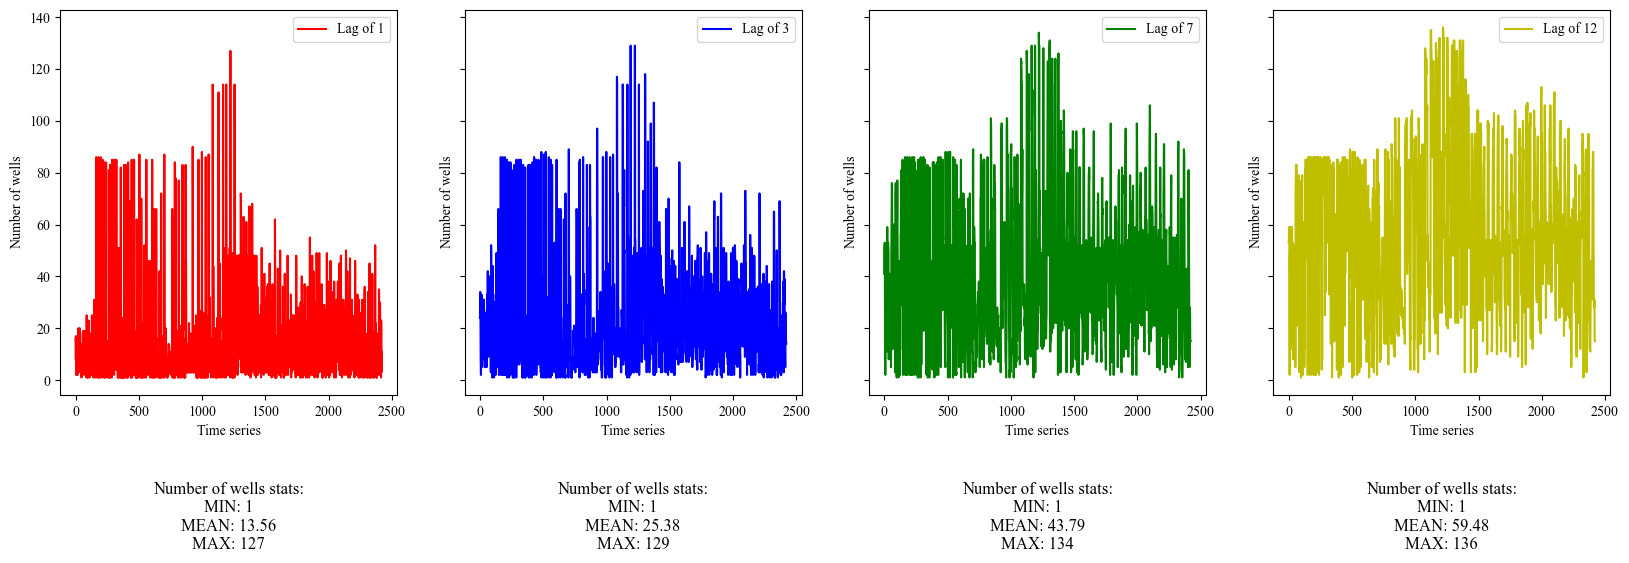

In [6]:
colors = ['r', 'b', 'g', 'y']

fig, axs = plt.subplots(nrows=1, ncols=4,figsize=(20,5), sharex=True, sharey=True)
for i, ax in enumerate(axs):
    data = np.array(shared_dates[shared_dates.index.get_level_values('Lag')==lags[i]]['Number of wells'])
    axs[i].plot(data, color=colors[i], label='Lag of '+str(lags[i]))
    axs[i].legend(loc="upper right")
    axs[i].set_xlabel('Time series')
    axs[i].set_ylabel('Number of wells')
    stats_text = str('Number of wells stats:\nMIN: {}\nMEAN: {}\nMAX: {}'.format(data.min(), round(data.mean(), 2), data.max()))
    axs[i].text(0.5,-0.4, stats_text, size=12, ha="center", transform=axs[i].transAxes)

As we can see, the average number of wells increases significantly as we increase the lag.
<br> With this insight, we can determine which lag is most suitable for our data. For demonstration purpose, we will continue the rest of the examples with a lag of 12.
<br><br> `getJointData()` takes `getCleanData()` one step further and saves the data according to the specified lag. You’ll notice that the index is no long a single date but a range of dates. The new range is (date - lag) through (date + lag).

In [7]:
lag = 12
jointData = pylenm_df.getJointData(analytes, lag=lag)
jointData

GENERATING DATA WITH A LAG OF 12.
Progress:
1%, 2%, 3%, 4%, 5%, 6%, 7%, 8%, 9%, 10%, 11%, 12%, 13%, 14%, 15%, 16%, 17%, 18%, 19%, 20%, 21%, 22%, 23%, 24%, 25%, 26%, 27%, 28%, 29%, 30%, 31%, 32%, 33%, 34%, 35%, 36%, 37%, 38%, 39%, 40%, 41%, 42%, 43%, 44%, 45%, 46%, 47%, 48%, 49%, 50%, 51%, 52%, 53%, 54%, 55%, 56%, 57%, 58%, 59%, 60%, 61%, 62%, 63%, 64%, 65%, 66%, 67%, 68%, 69%, 70%, 71%, 72%, 73%, 74%, 75%, 76%, 77%, 78%, 79%, 80%, 81%, 82%, 83%, 84%, 85%, 86%, 87%, 88%, 89%, 90%, 91%, 92%, 93%, 94%, 95%, 96%, 97%, 98%, 99%, Completed


ANALYTE_NAME            DEPTH_TO_WATER                                    \
STATION_ID                    FBI-014D FBI-015D FBI-017D FEX-004 FIB-001   
1989-12-20 - 1990-01-13            NaN      NaN      NaN     NaN     NaN   
1989-12-21 - 1990-01-14            NaN      NaN      NaN     NaN     NaN   
1989-12-22 - 1990-01-15            NaN      NaN      NaN     NaN     NaN   
1989-12-25 - 1990-01-18            NaN      NaN      NaN     NaN     NaN   
1989-12-26 - 1990-01-19            NaN      NaN      NaN     NaN     NaN   
...                                ...      ...      ...     ...     ...   
2015-08-29 - 2015-09-22            NaN      NaN      NaN     NaN     NaN   
2015-09-09 - 2015-10-03           17.4     15.4    25.16     NaN     NaN   
2015-09-10 - 2015-10-04           17.4     15.4    25.16     NaN     NaN   
2015-09-11 - 2015-10-05           17.4     15.4    25.16     NaN     NaN   
2015-09-12 - 2015-10-06           17.4     15.4    25.16     NaN     NaN   

ANALYTE_NAME                                                         ...  \
STATION_ID              FIB-008 FOB-001D FOB-002C FOB-002D FOB-013D  ...   
1989-12-20 - 1990-01-13     NaN      NaN      NaN      NaN      NaN  ...   
1989-12-21 - 1990-01-14     NaN      NaN      NaN      NaN      NaN  ...   
1989-12-22 - 1990-01-15     NaN      NaN      NaN      NaN      NaN  ...   
1989-12-25 - 1990-01-18     NaN      NaN      NaN      NaN      NaN  ...   
1989-12-26 - 1990-01-19     NaN      NaN      NaN      NaN      NaN  ...   
...                         ...      ...      ...      ...      ...  ...   
2015-08-29 - 2015-09-22     NaN      NaN      NaN      NaN      NaN  ...   
2015-09-09 - 2015-10-03     NaN      NaN      NaN      NaN     21.5  ...   
2015-09-10 - 2015-10-04     NaN      NaN      NaN      NaN     21.5  ...   
2015-09-11 - 2015-10-05     NaN      NaN      NaN      NaN     21.5  ...   
2015-09-12 - 2015-10-06     NaN      NaN      NaN      NaN     21.5  ...   

ANALYTE_NAME            URANIUM-238                                      \
STATION_ID                 FSP-002B FSP-002C FSP-012A FSP-047A FSP-072A   
1989-12-20 - 1990-01-13         NaN      NaN      NaN      NaN      NaN   
1989-12-21 - 1990-01-14         NaN      NaN      NaN      NaN      NaN   
1989-12-22 - 1990-01-15         NaN      NaN      NaN      NaN      NaN   
1989-12-25 - 1990-01-18         NaN      NaN      NaN      NaN      NaN   
1989-12-26 - 1990-01-19         NaN      NaN      NaN      NaN      NaN   
...                             ...      ...      ...      ...      ...   
2015-08-29 - 2015-09-22       0.237      NaN     1.02      NaN    0.104   
2015-09-09 - 2015-10-03         NaN      NaN      NaN      NaN      NaN   
2015-09-10 - 2015-10-04         NaN      NaN      NaN      NaN      NaN   
2015-09-11 - 2015-10-05         NaN      NaN      NaN      NaN      NaN   
2015-09-12 - 2015-10-06         NaN      NaN      NaN      NaN      NaN   

ANALYTE_NAME                                                          
STATION_ID              FSP-072B FSP-204A FSP-226A FSP-249A FSP-249B  
1989-12-20 - 1990-01-13      NaN      NaN      NaN      NaN      NaN  
1989-12-21 - 1990-01-14      NaN      NaN      NaN      NaN      NaN  
1989-12-22 - 1990-01-15      NaN      NaN      NaN      NaN      NaN  
1989-12-25 - 1990-01-18      NaN      NaN      NaN      NaN      NaN  
1989-12-26 - 1990-01-19      NaN      NaN      NaN      NaN      NaN  
...                          ...      ...      ...      ...      ...  
2015-08-29 - 2015-09-22   0.0457    0.479      NaN    0.287    0.169  
2015-09-09 - 2015-10-03      NaN      NaN      NaN      NaN      NaN  
2015-09-10 - 2015-10-04      NaN      NaN      NaN      NaN      NaN  
2015-09-11 - 2015-10-05      NaN      NaN      NaN      NaN      NaN  
2015-09-12 - 2015-10-06      NaN      NaN      NaN      NaN      NaN  

[2421 rows x 773 columns]

# Correlation analysis functions

## plot_corr_by_well()

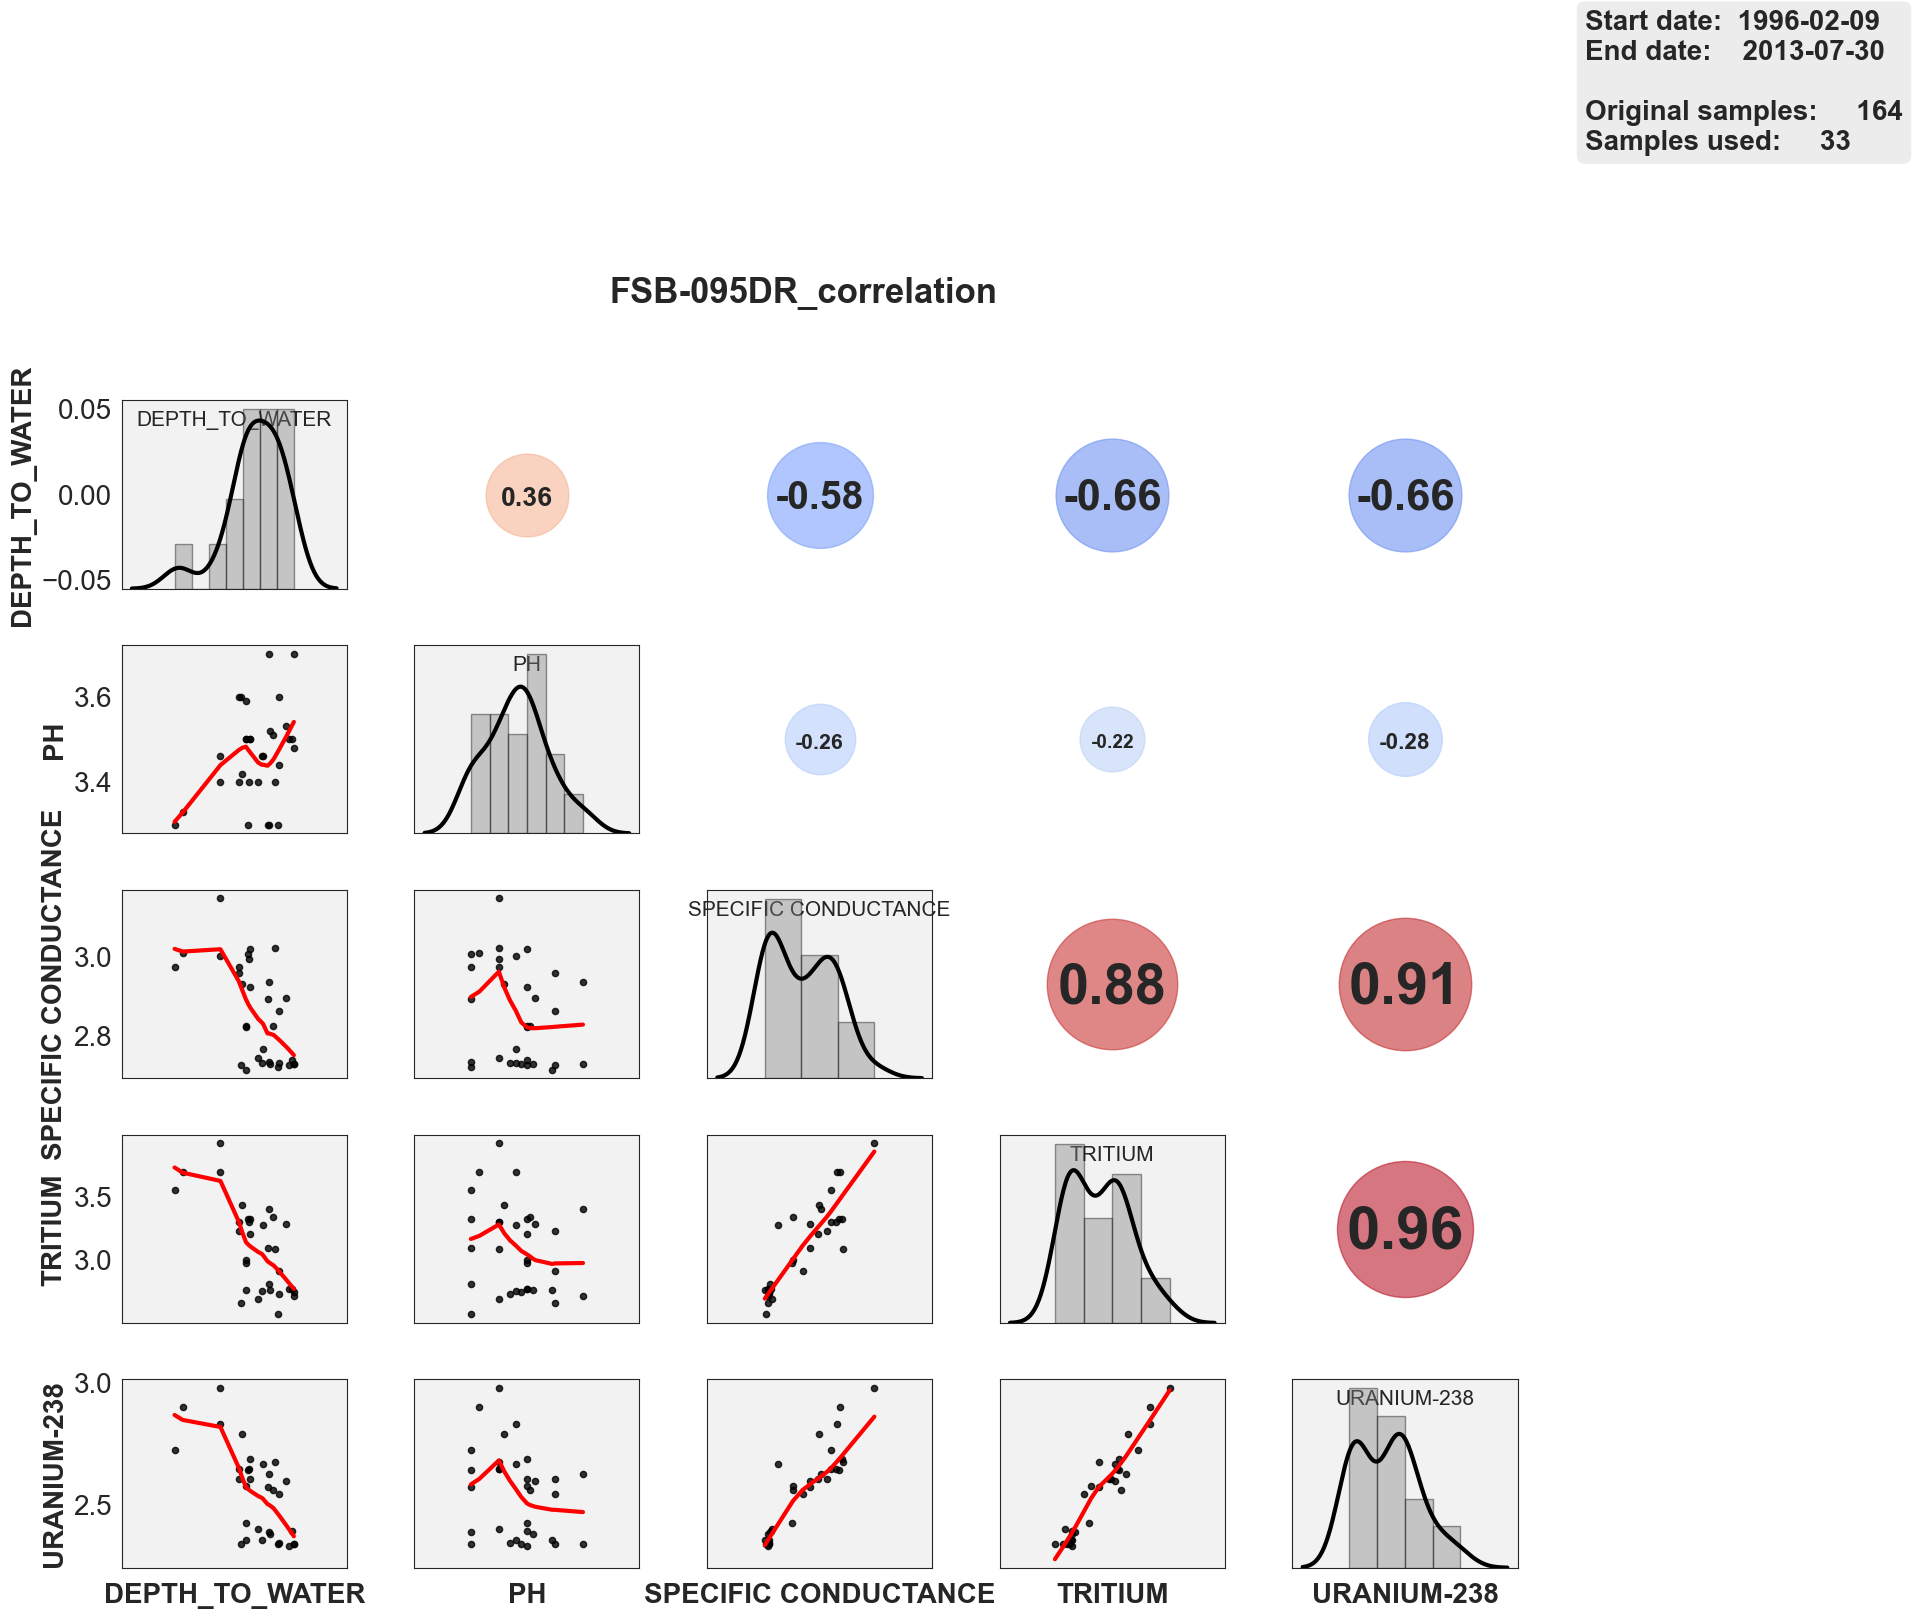

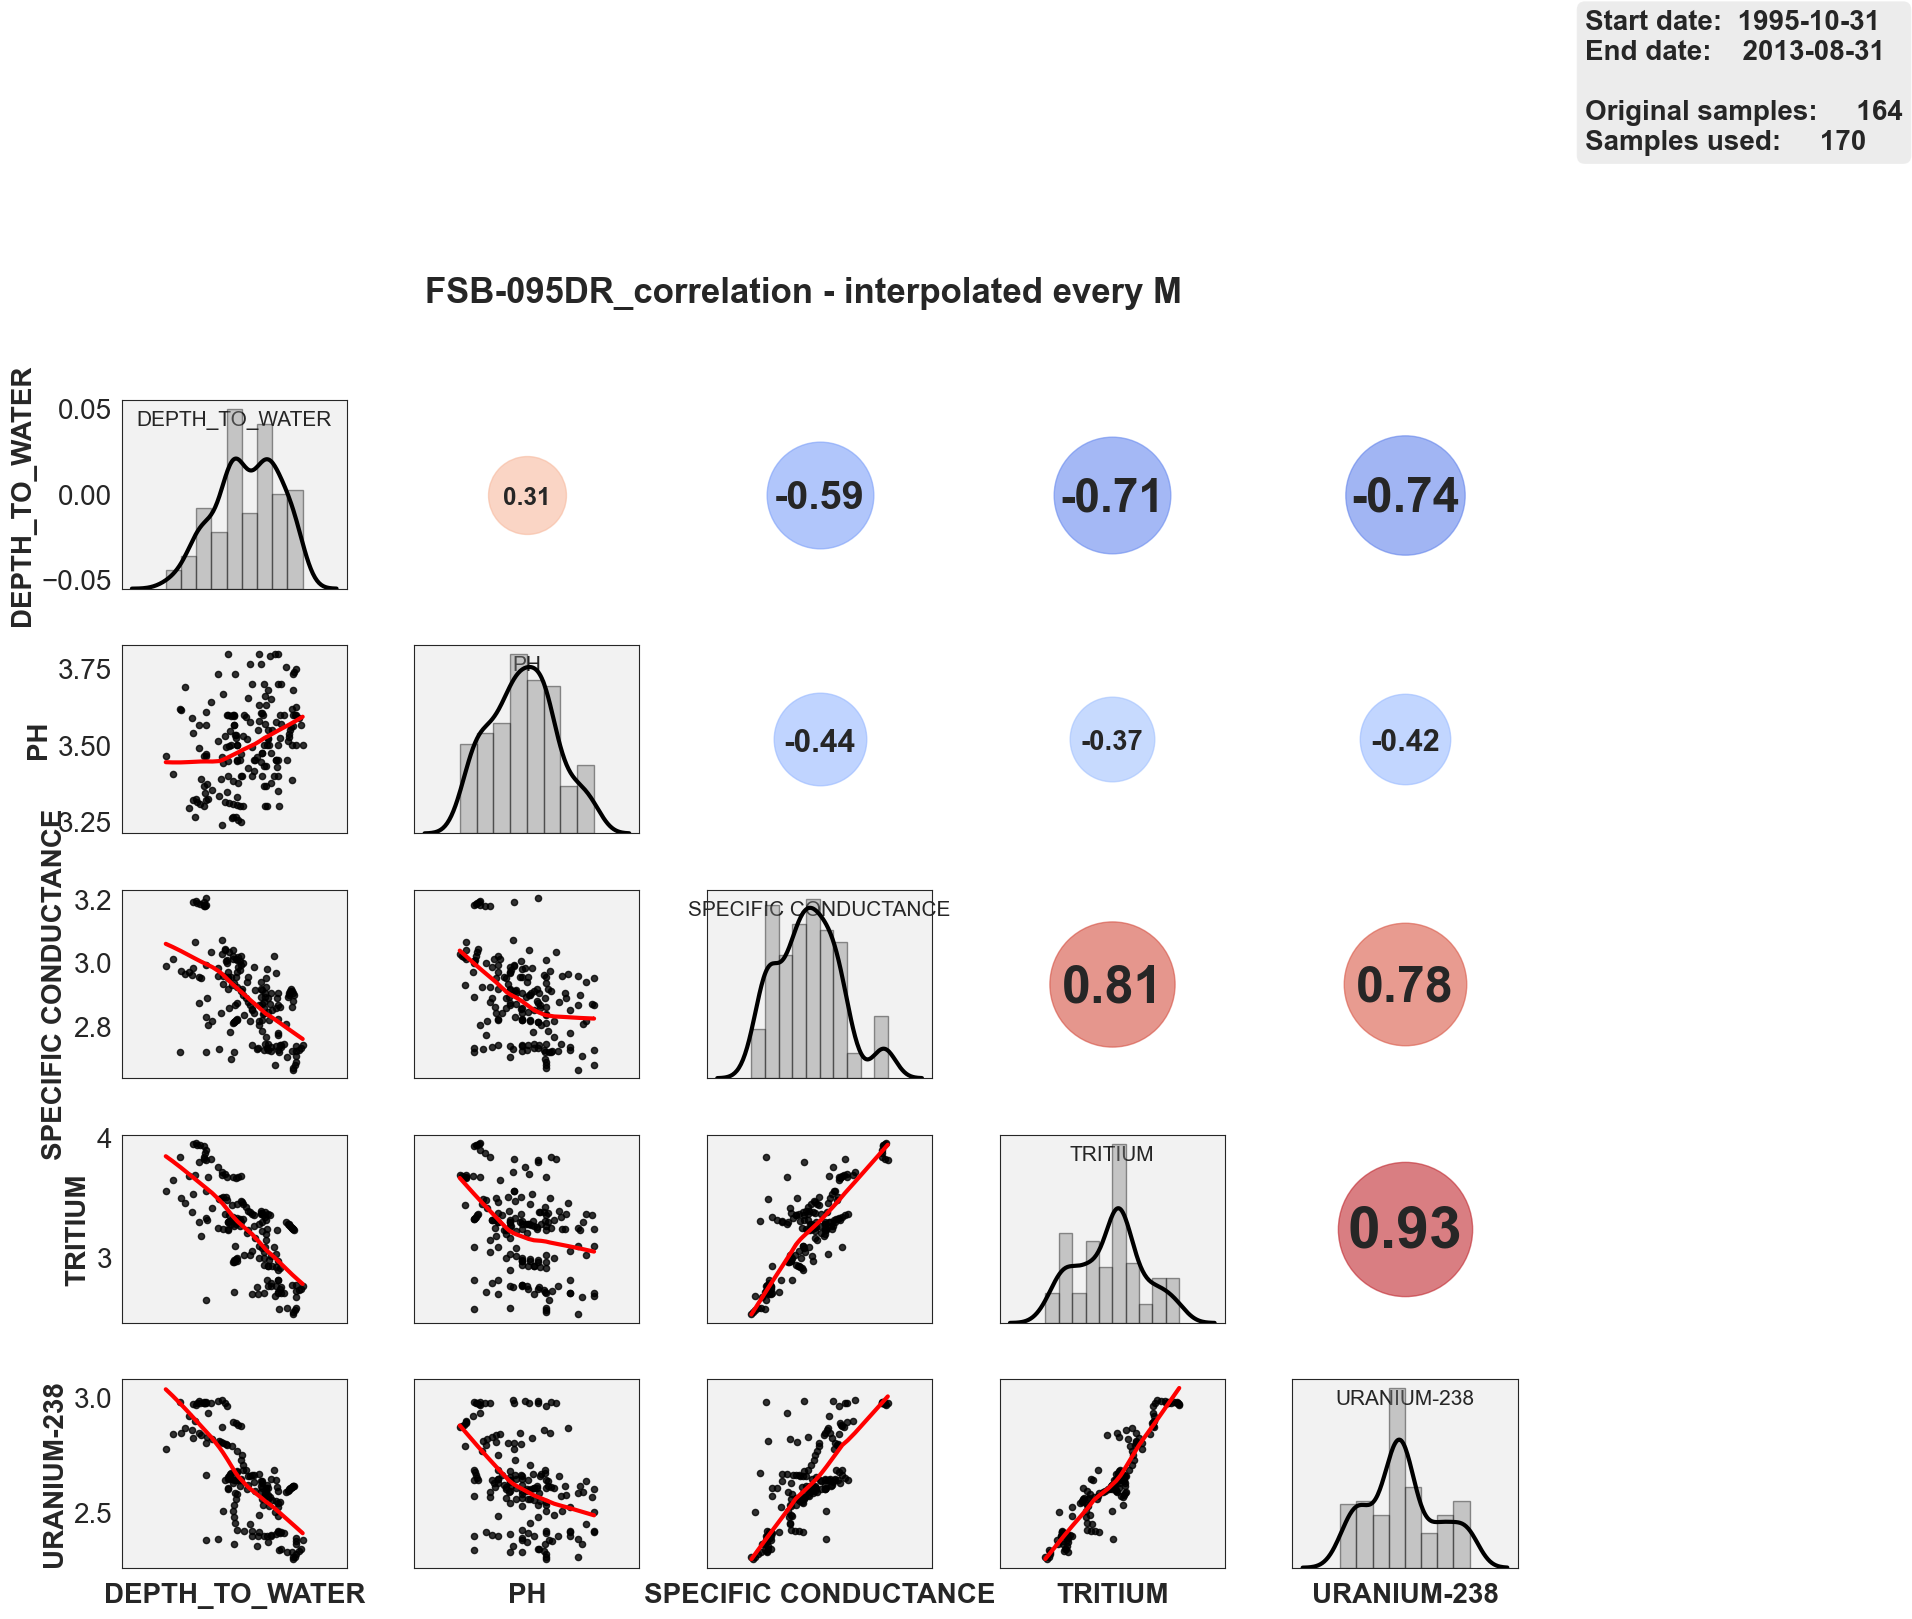

In [8]:
pylenm_df.plot_corr_by_well(well_name='FSB-095DR', analytes=analytes, log_transform=True, remove_outliers=True, z_threshold=1.3, remove=['1999-07-28'], no_log=['PH'])


pylenm_df.plot_corr_by_well(well_name='FSB-095DR', analytes=analytes,
                            interpolate=True, frequency='M', 
                            remove_outliers=True, z_threshold=1.3, log_transform=True, remove=['1999-07-28'], no_log=['PH'])

## plot_corr_by_date_range()

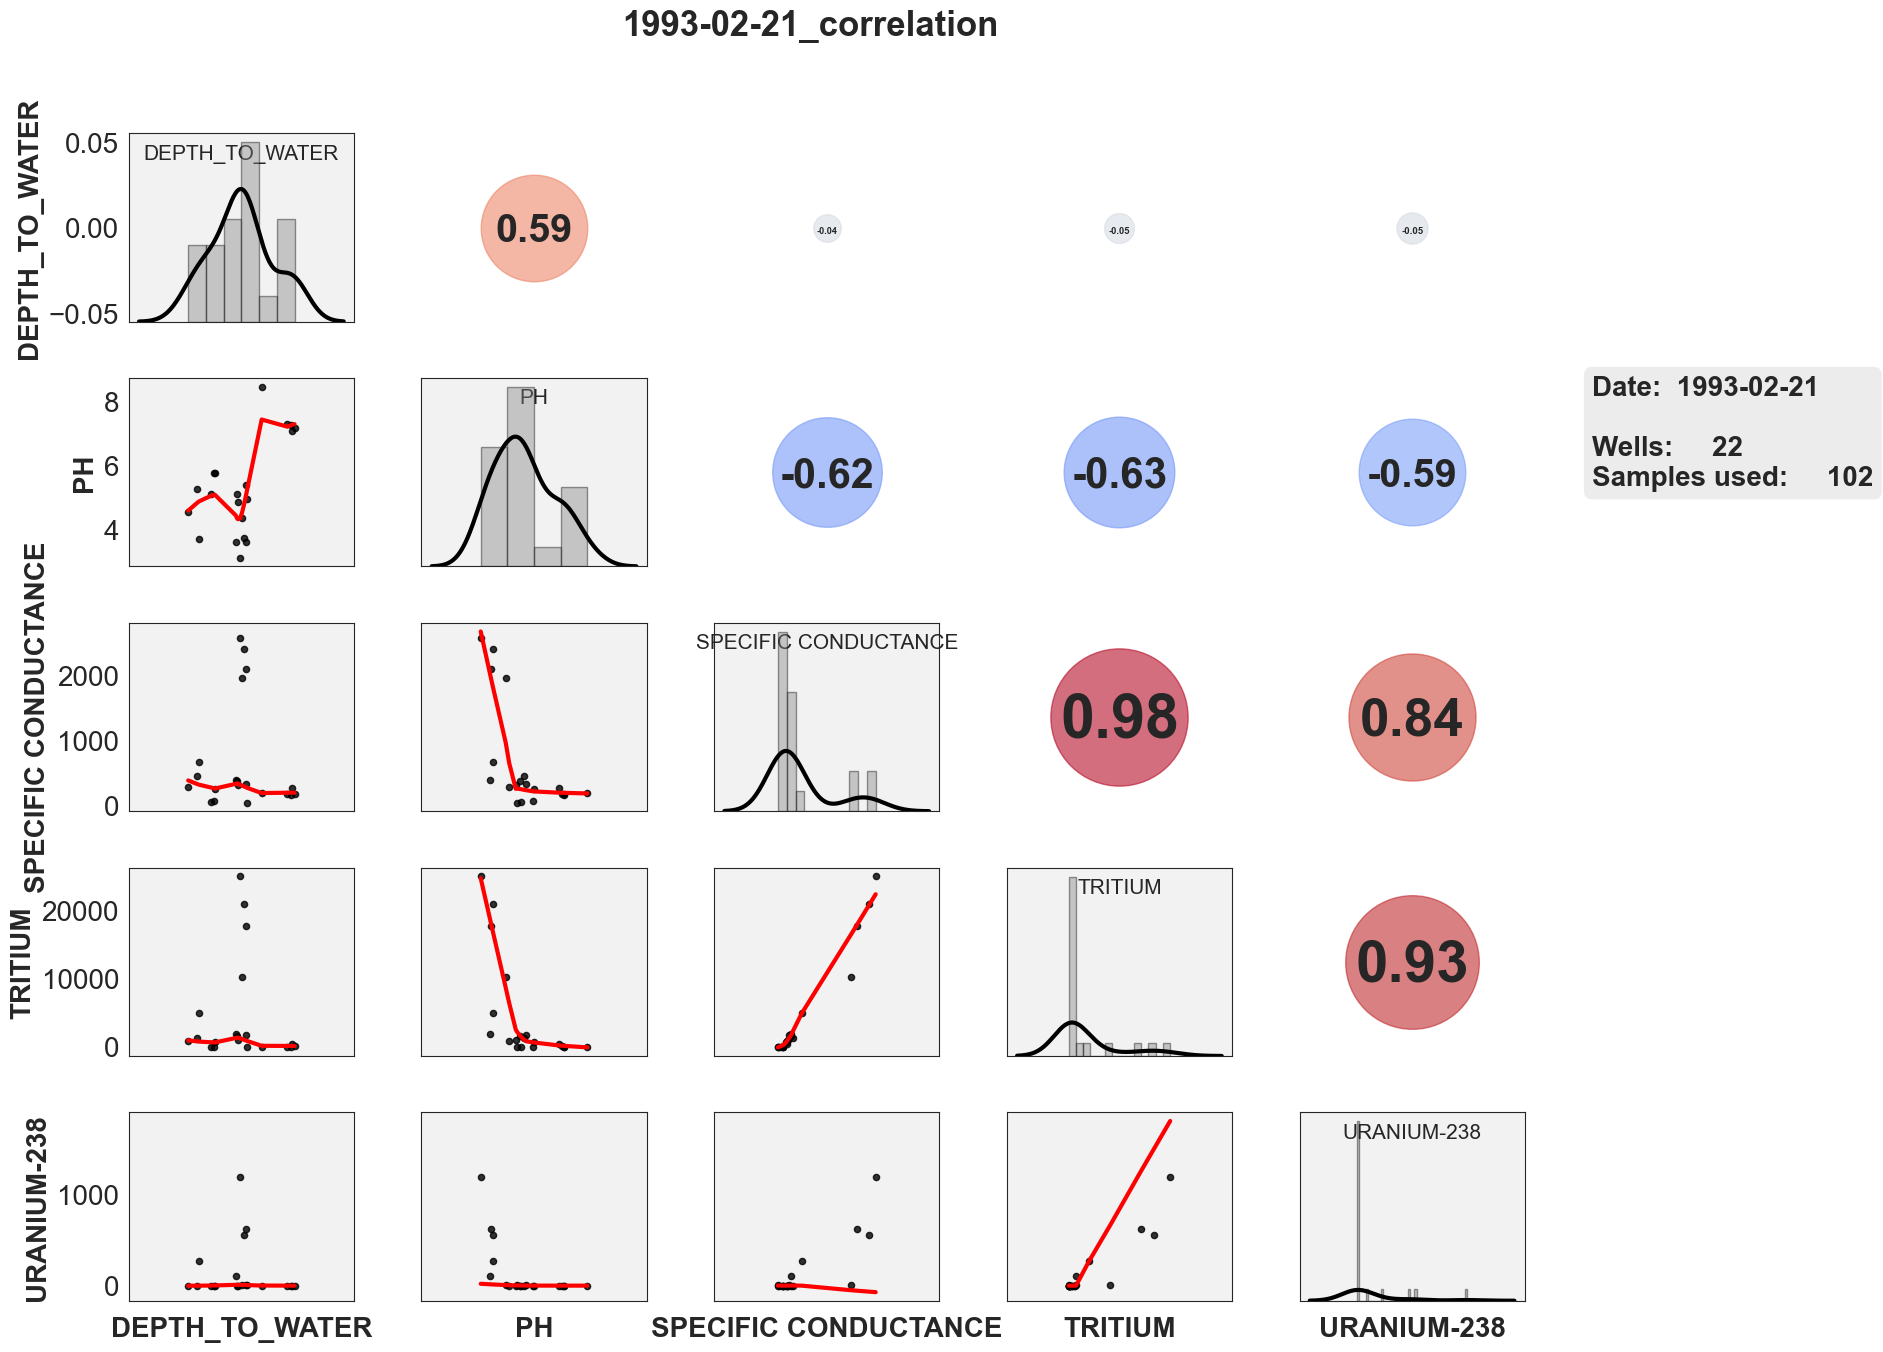

In [11]:
corr_by_date_demo_df = pylenm_df.plot_corr_by_date_range('1993-02-21', analytes=analytes, returnData=True)

In [12]:
corr_by_date_demo_df

ANALYTE_NAME,DEPTH_TO_WATER,PH,SPECIFIC CONDUCTANCE,TRITIUM,URANIUM-238
STATION_ID,,,,,
FSB-091C,66.76,4.875,314.500000,946.00,1.81
FSB-091D,63.92,3.600,381.000000,1820.00,102.00
FSB-093C,65.75,5.100,374.000000,1510.00,1.00
FSB-094C,71.40,4.370,1955.000000,10200.00,10.30
FSB-094DR,69.11,3.115,2585.000000,25000.00,1190.00
FSB-096AR,127.52,7.315,175.500000,9.06,1.00
FSB-097A,133.39,7.070,266.333333,335.00,1.00
FSB-097C,76.40,3.615,2095.000000,17700.00,622.50
FSB-097D,73.88,3.735,2415.000000,20900.00,559.00


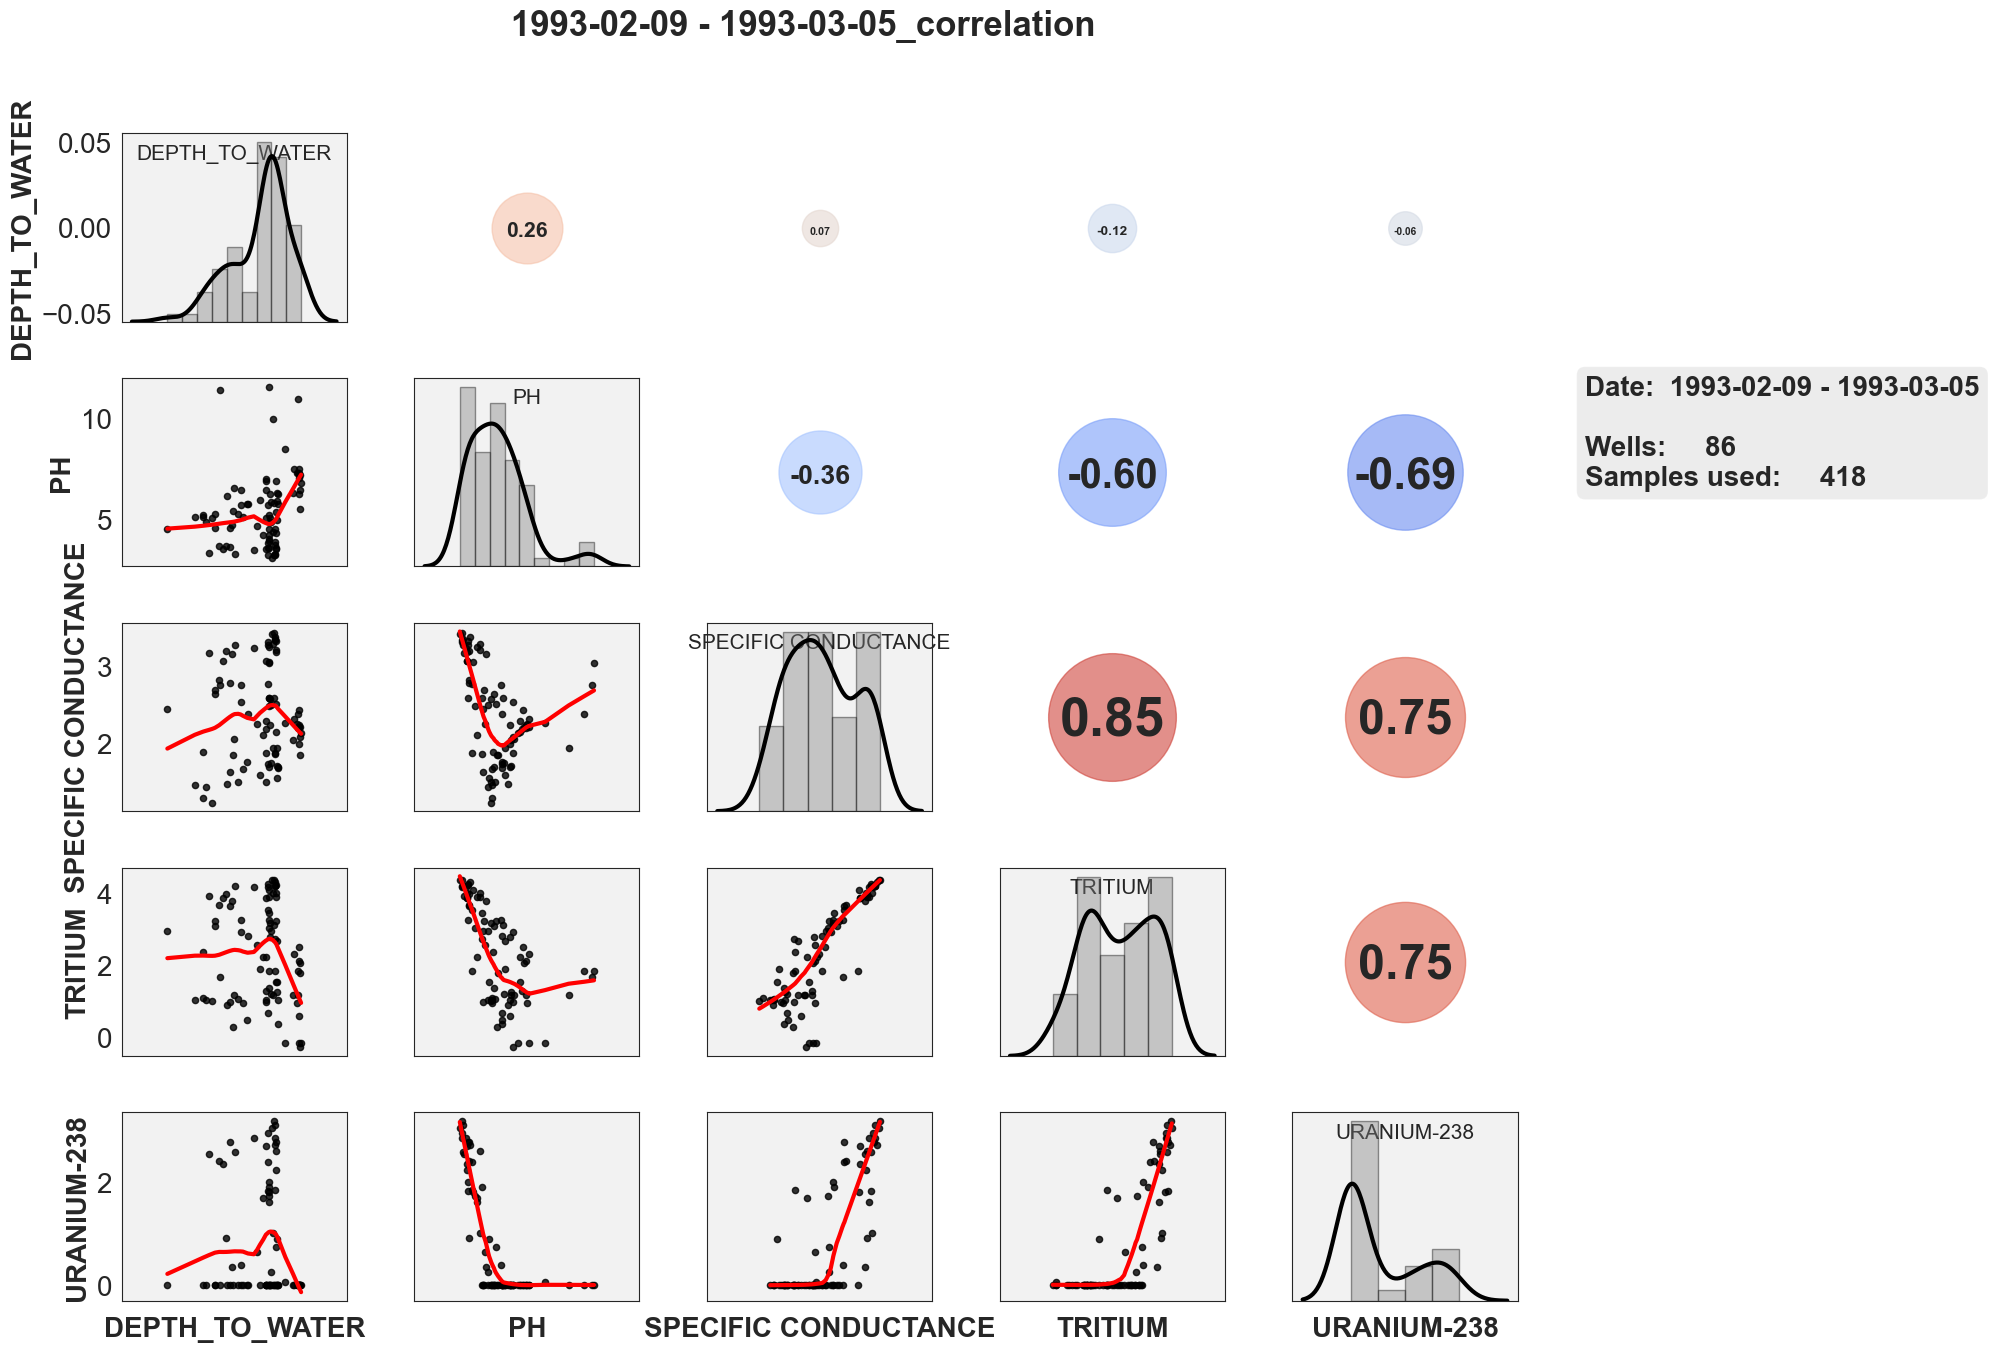

In [10]:
pylenm_df.plot_corr_by_date_range('1993-02-21', lag=lag, analytes=analytes, log_transform=True, no_log=['PH'])

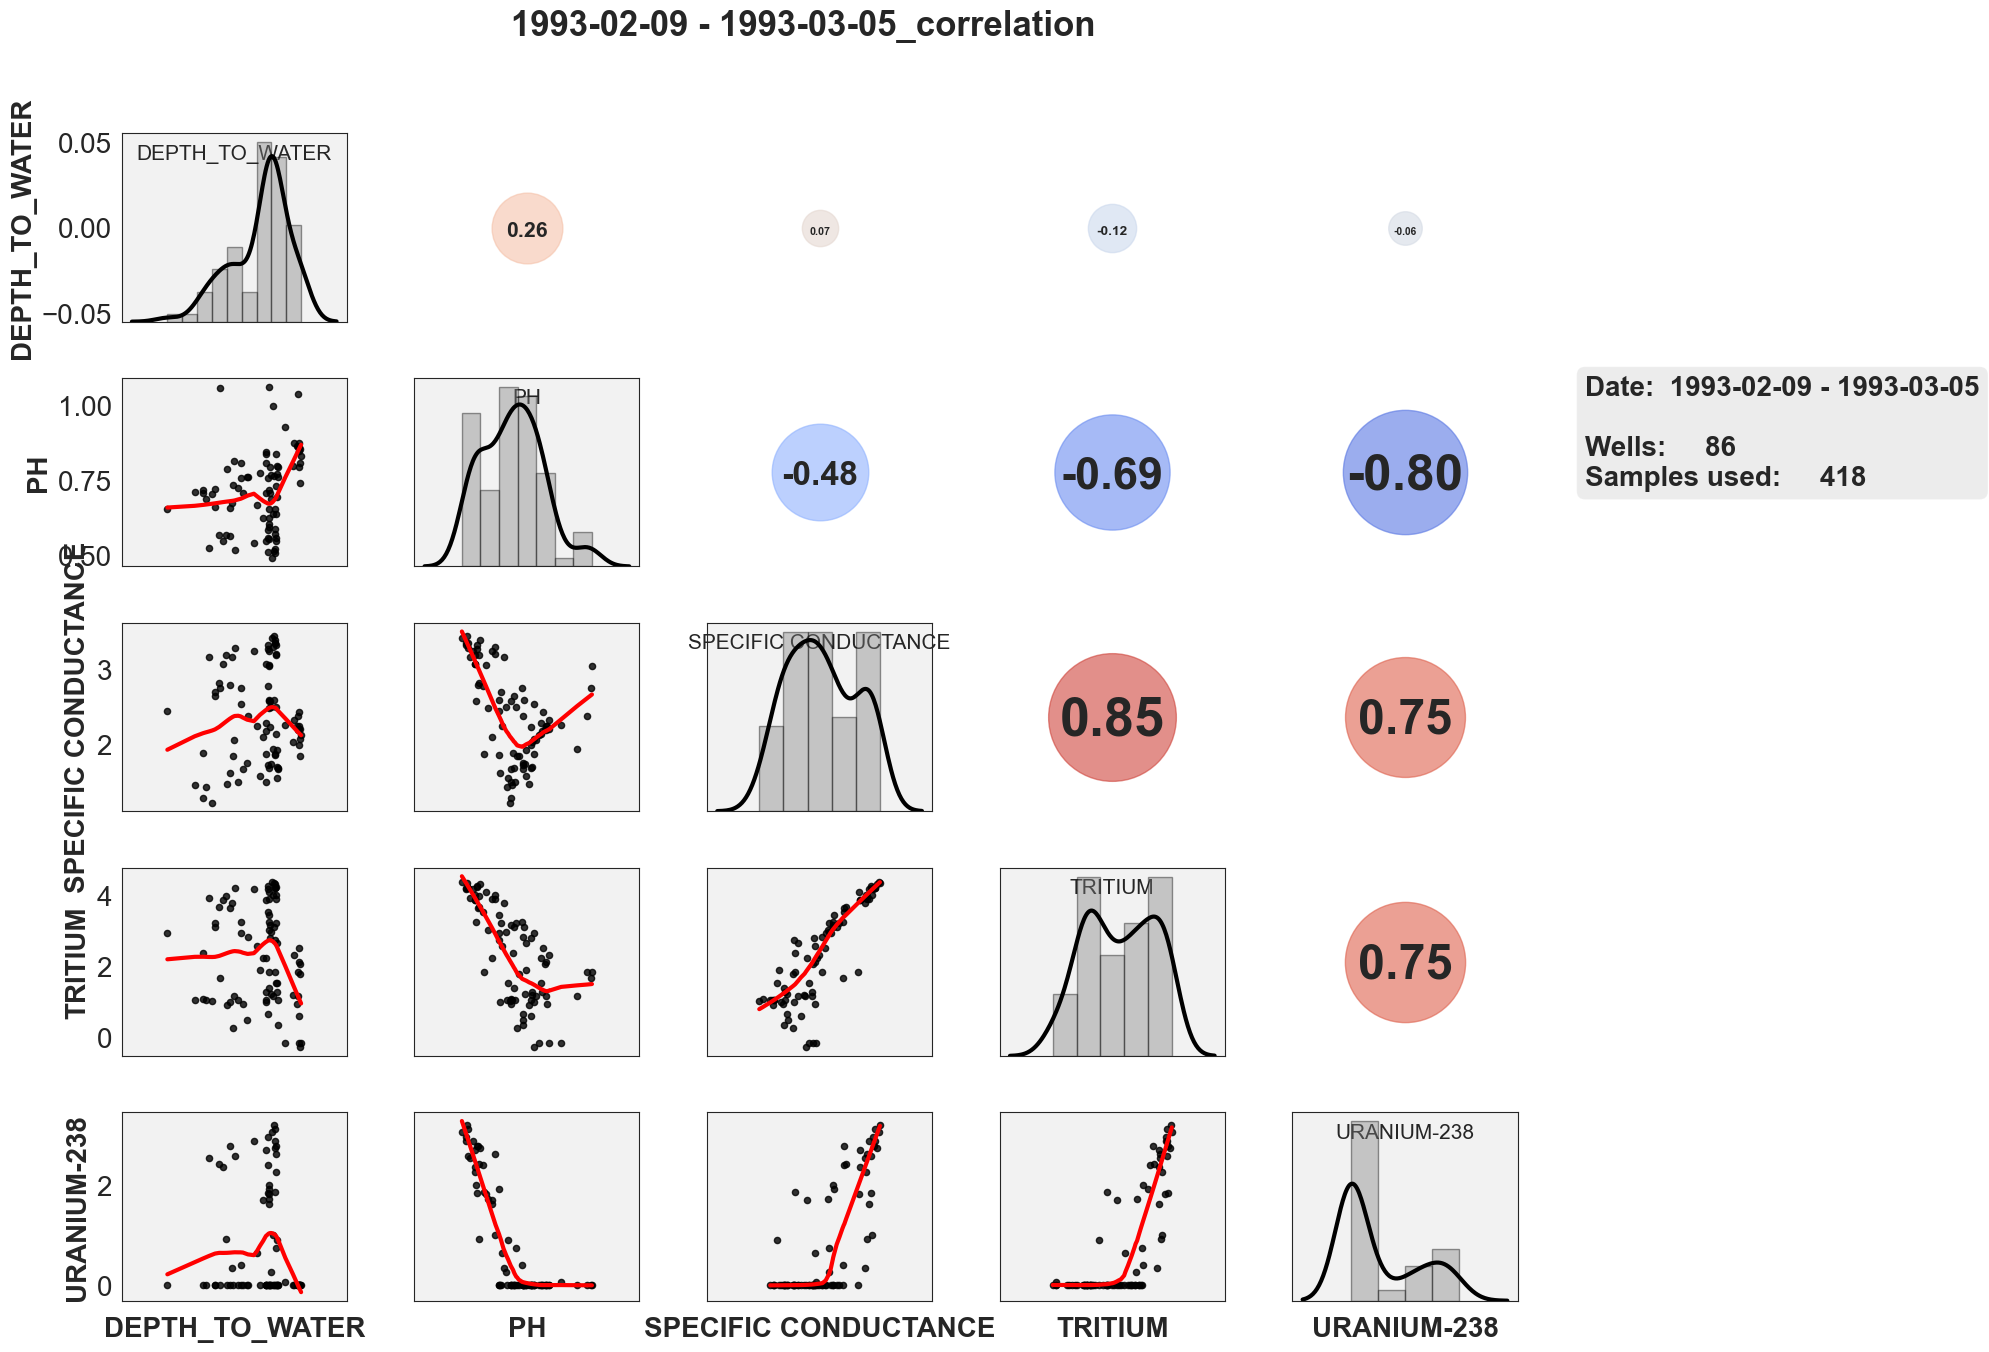

In [13]:
pylenm_df.plot_corr_by_date_range('1993-02-21', lag=lag, analytes=analytes, log_transform=True)

## plot_corr_by_year()

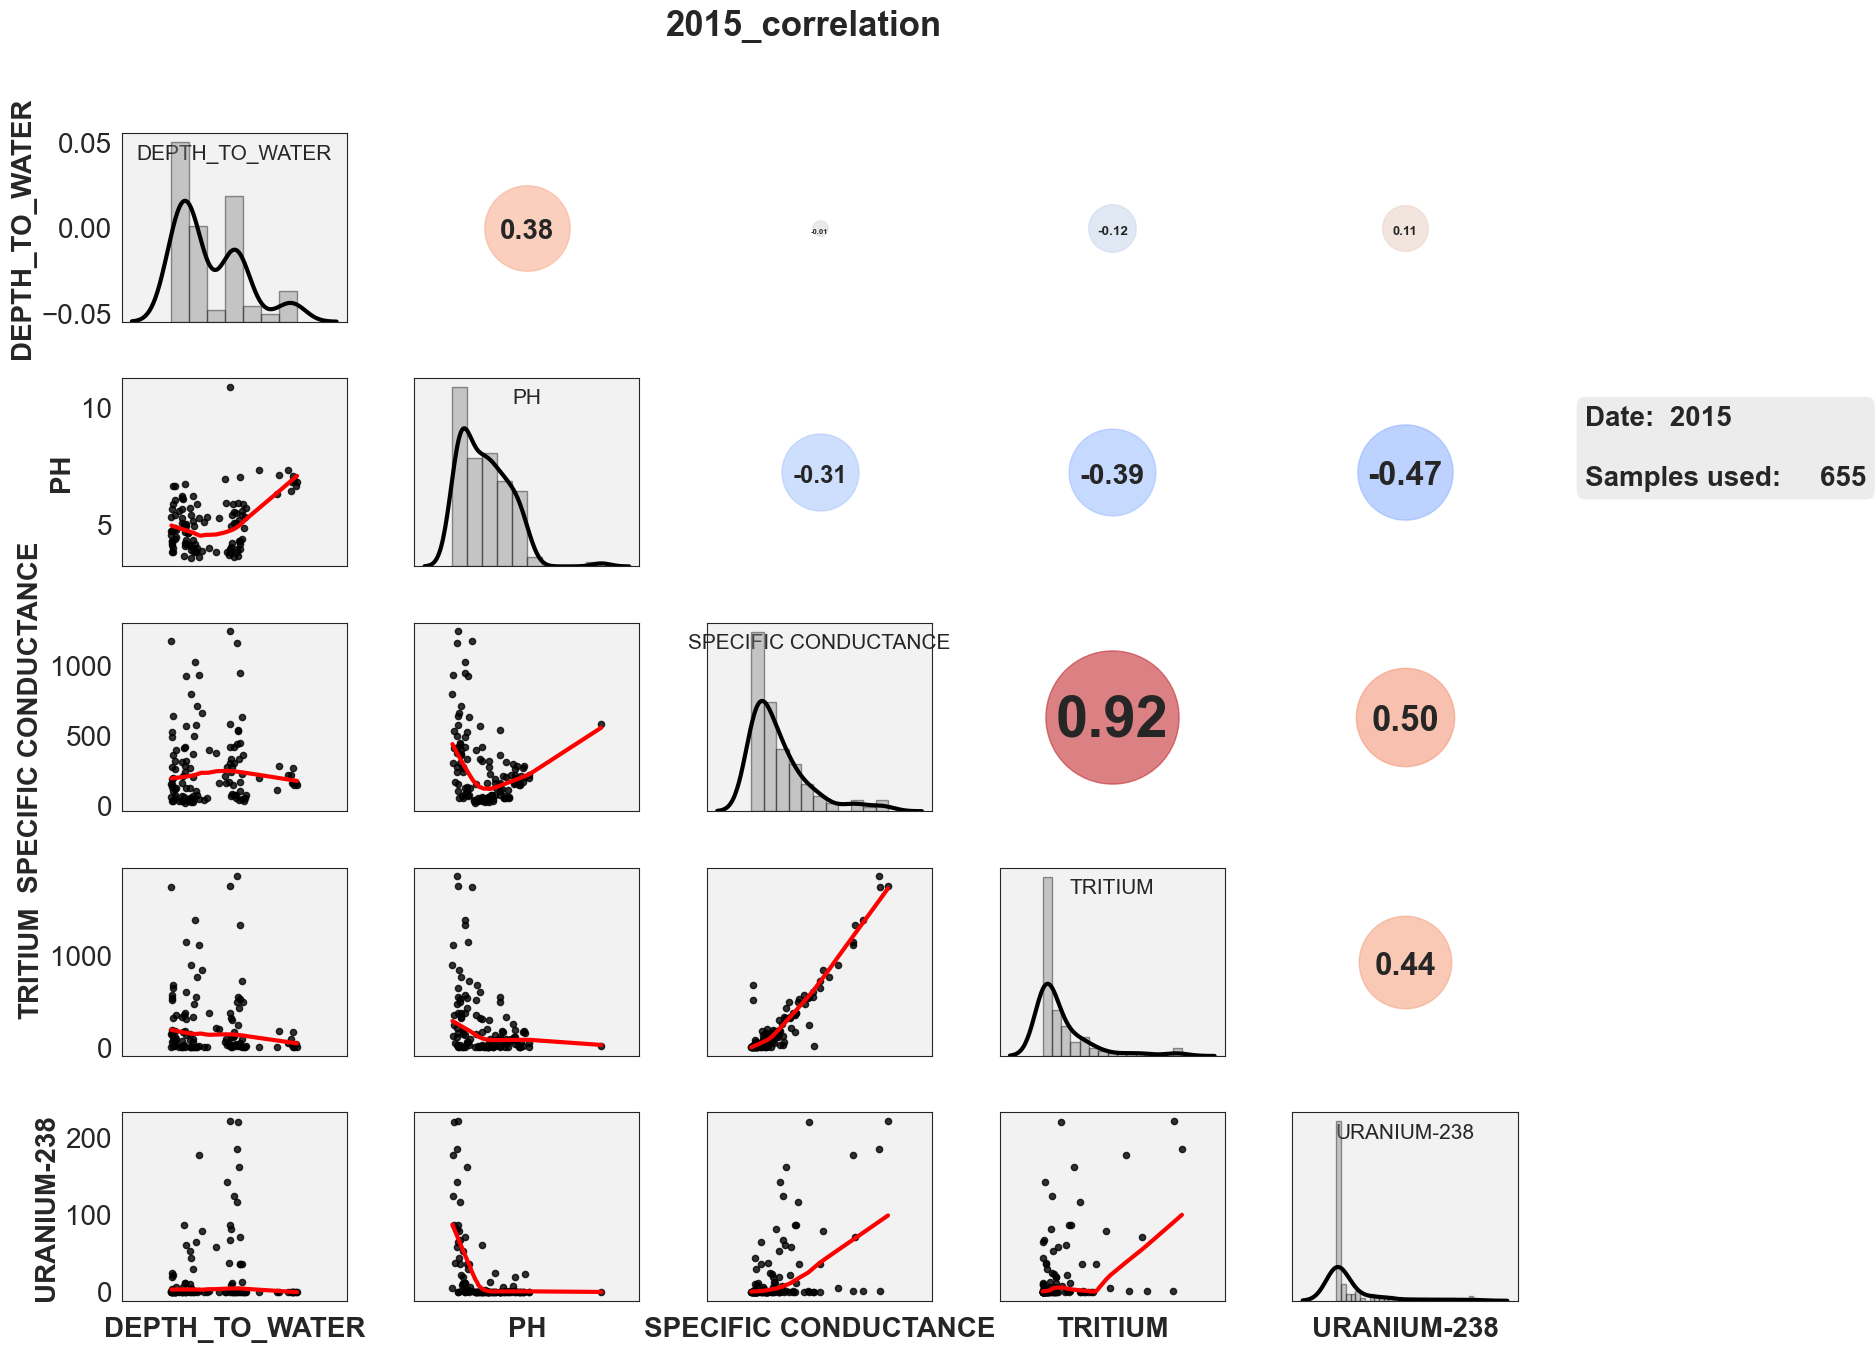

In [14]:
pylenm_df.plot_corr_by_year(2015, analytes=analytes, remove_outliers=True, z_threshold=3, no_log=['PH'])

# PCA functions

## plot_PCA_by_date()

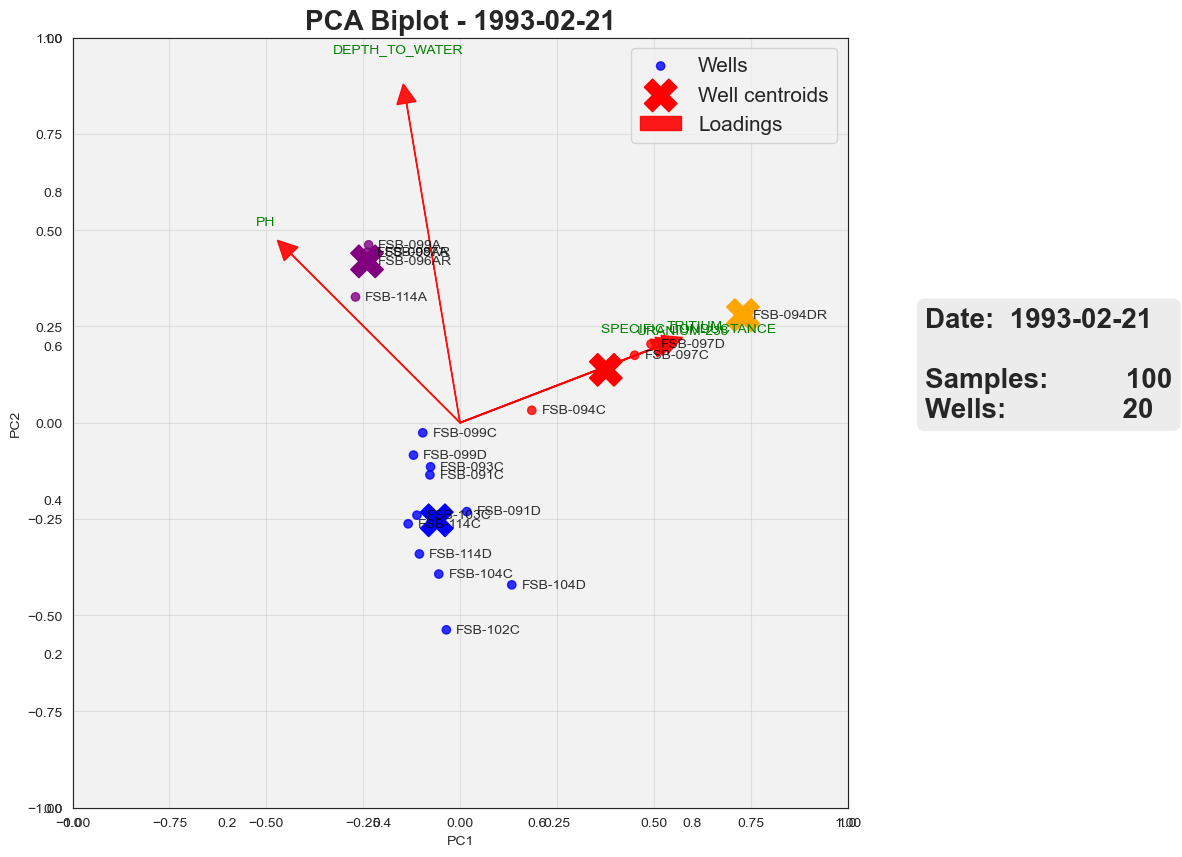

In [15]:
pylenm_df.plot_PCA_by_date('1993-02-21', analytes)

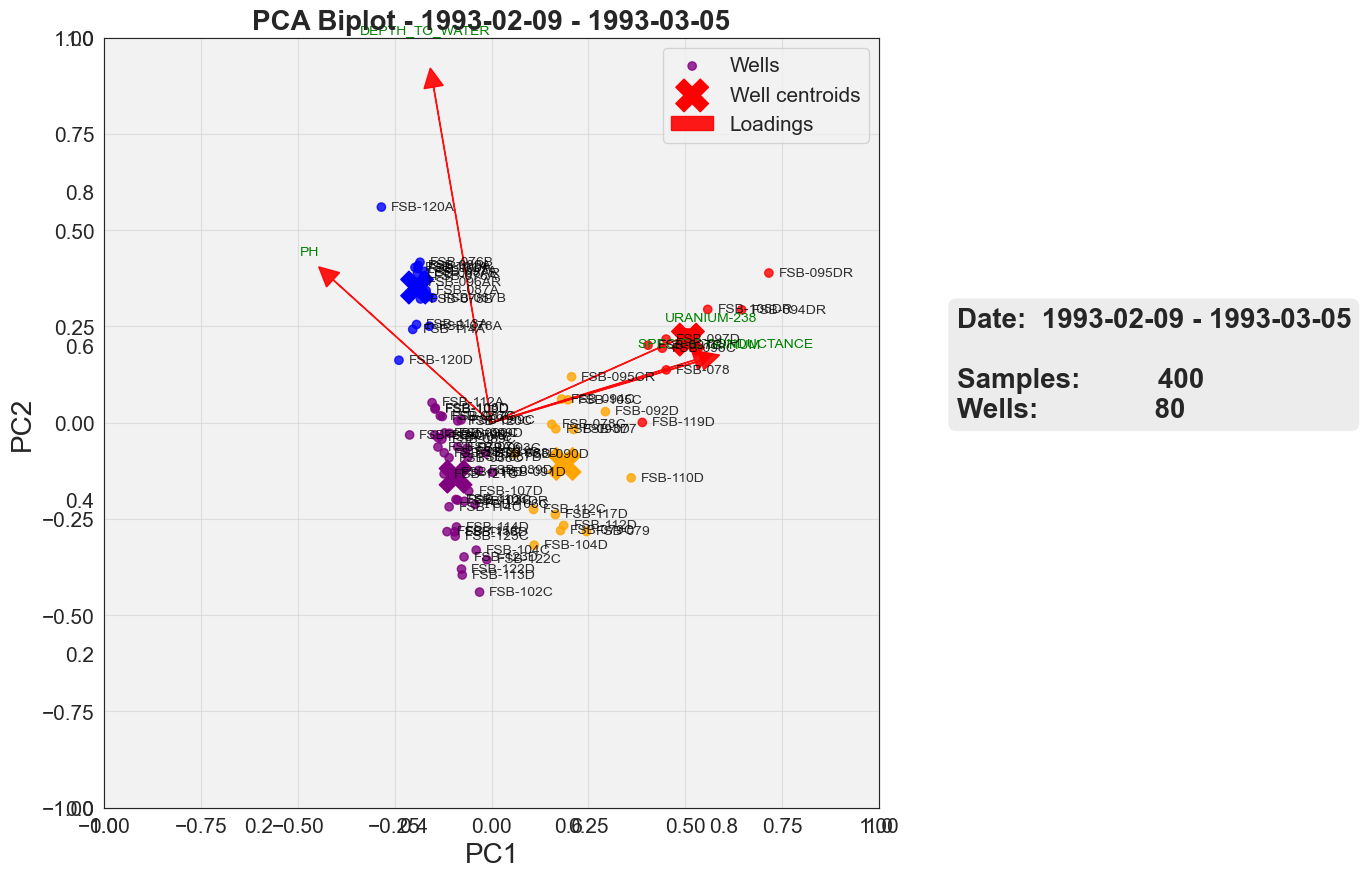

In [16]:
pylenm_df.plot_PCA_by_date('1993-02-21', analytes, lag=lag)

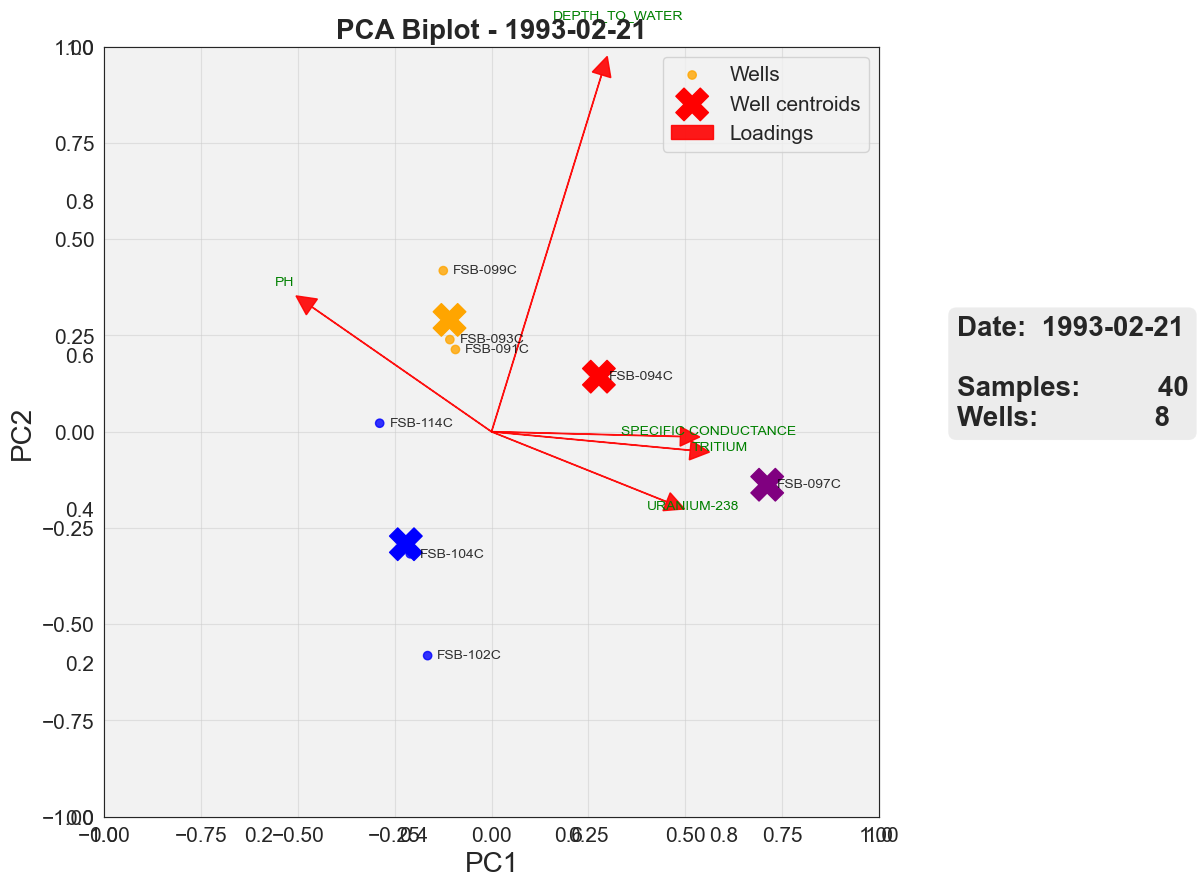

In [17]:
 pylenm_df.plot_PCA_by_date('1993-02-21', analytes, lag=0, filter=True, col='AQUIFER', equals=['LAZ_UTRAU'])

## plot_PCA_by_well()

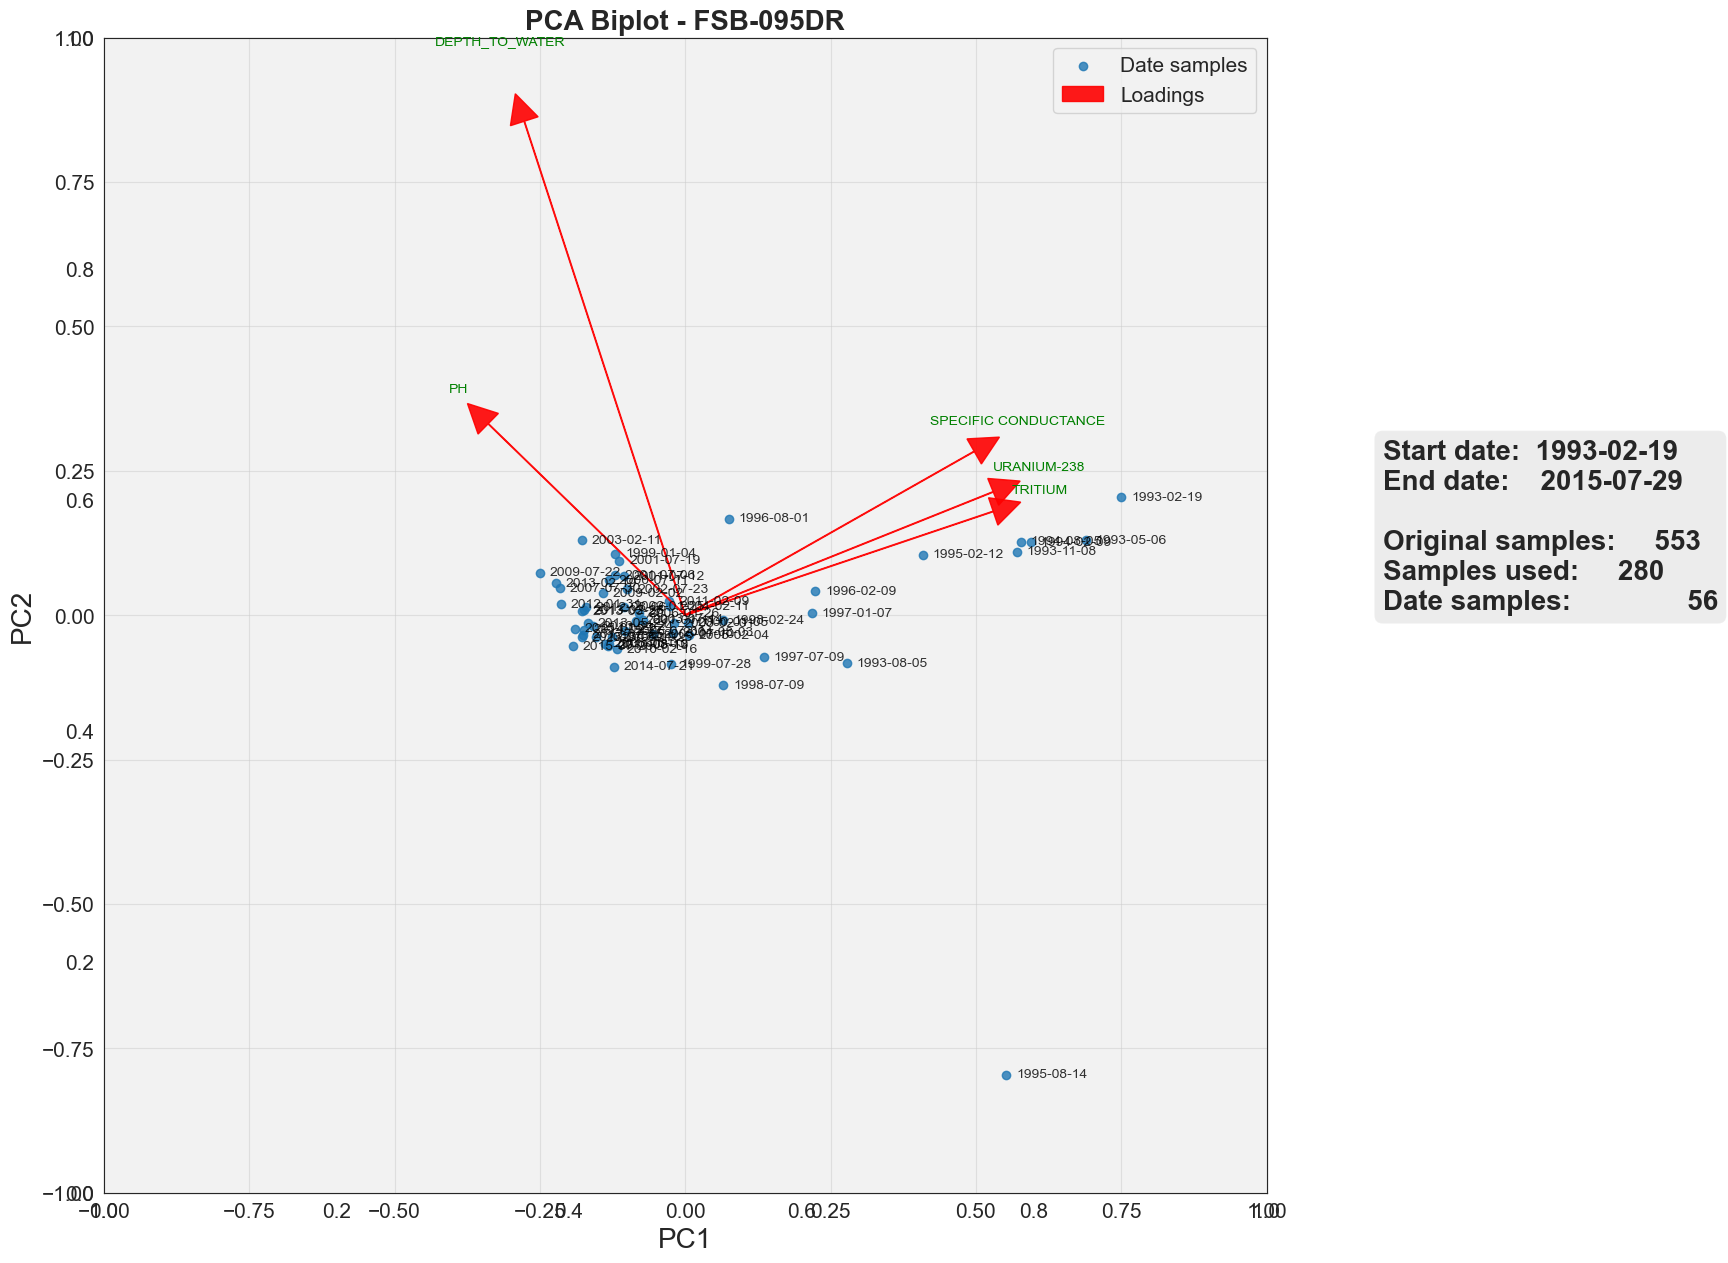

In [19]:
pylenm_df.plot_PCA_by_well(well_name='FSB-095DR', analytes=analytes)

## plot_PCA_by_year()

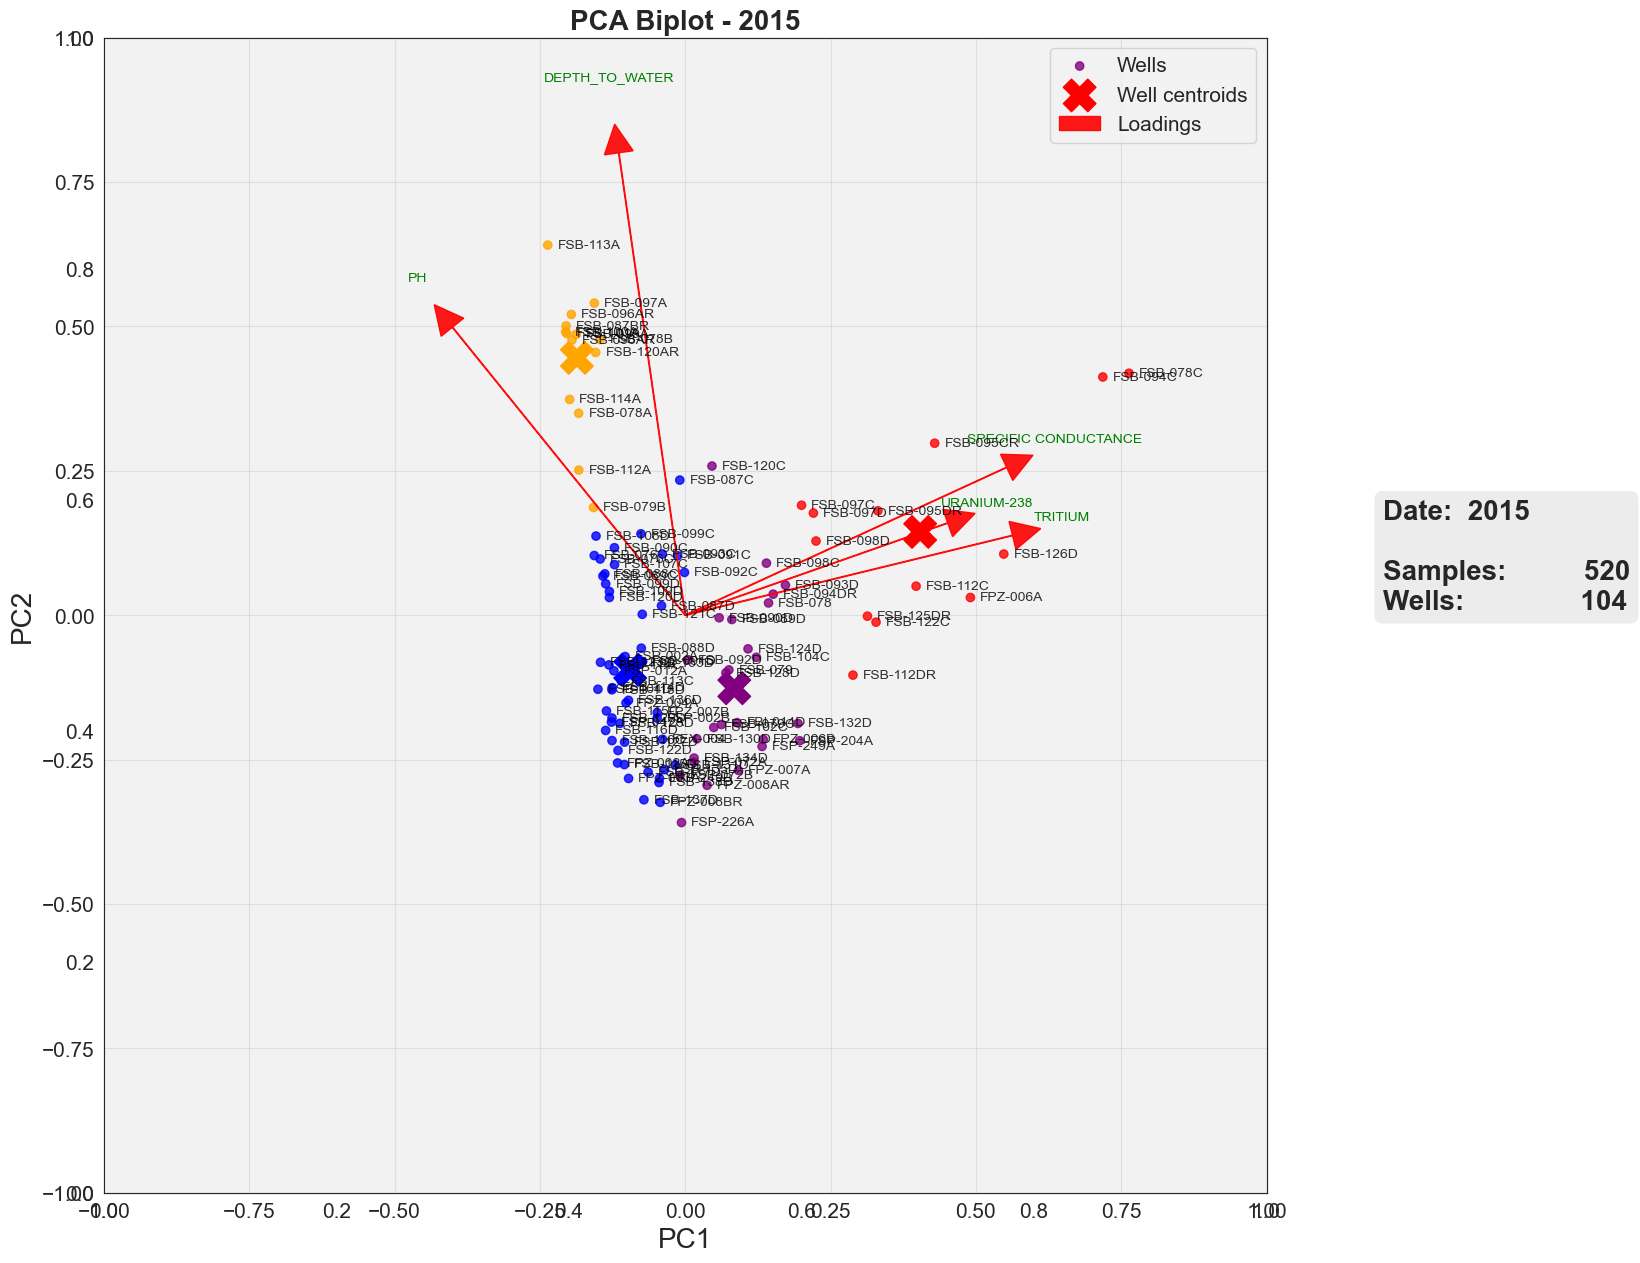

In [20]:
pylenm_df.plot_PCA_by_year(2015, analytes=analytes)

# Clustering functions

In [21]:
tritium = pylenm_df.interpolate_wells_by_analyte('TRITIUM', frequency='2W')
tritium = np.log10(tritium)
tritium = tritium.dropna(axis=1)
tritium

,FAS-091,FAS-092,FAS-093,FAS-096,FBI-014D,FBI-015D,FBI-017D,FEX-004,FIB-001,FIB-008,...,FSP-002B,FSP-002C,FSP-012A,FSP-047A,FSP-072A,FSP-072B,FSP-204A,FSP-226A,FSP-249A,FSP-249B
1990-01-07,2.442409,2.594370,2.378118,2.314603,2.967033,2.778449,2.846947,2.688923,2.167317,3.017033,...,2.194799,1.916614,1.981405,2.721239,3.433601,3.200344,3.241746,2.219083,3.031973,2.667671
1990-01-21,2.442409,2.594370,2.378118,2.314603,2.967033,2.778449,2.846947,2.688923,2.167317,3.017033,...,2.194799,1.916614,1.981405,2.721239,3.433601,3.200344,3.241746,2.219083,3.031973,2.667671
1990-02-04,2.442409,2.594370,2.378118,2.314603,2.967033,2.778449,2.846947,2.688923,2.167317,3.017033,...,2.194799,1.916614,1.981405,2.721239,3.433601,3.200344,3.241746,2.219083,3.031973,2.667671
1990-02-18,2.442409,2.594370,2.378118,2.314603,2.967033,2.778449,2.846947,2.688923,2.167317,3.017033,...,2.194799,1.916614,1.981405,2.721239,3.433601,3.200344,3.241746,2.219083,3.031973,2.667671
1990-03-04,2.442409,2.594370,2.378118,2.314603,2.967033,2.778449,2.846947,2.688923,2.167317,3.017033,...,2.194799,1.916614,1.981405,2.721239,3.433601,3.200344,3.241746,2.219083,3.031973,2.667671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-08-02,2.294466,2.452767,2.210746,2.043087,2.465210,2.754348,2.743902,1.677835,2.167317,3.017033,...,1.862569,1.916454,1.843940,1.526339,2.784718,2.697517,2.851386,2.167317,2.732571,2.152420
2015-08-16,2.294466,2.452537,2.210142,2.046378,2.459392,2.754348,2.743902,1.681241,2.167317,3.017033,...,1.849774,1.916454,1.829459,1.526339,2.777979,2.701056,2.864909,2.167317,2.730995,2.153339
2015-08-30,2.294466,2.452306,2.209537,2.049644,2.459392,2.754348,2.743902,1.681241,2.167317,3.017033,...,1.836591,1.916454,1.814479,1.526339,2.771134,2.704567,2.878023,2.167317,2.729413,2.154257
2015-09-13,2.294466,2.452075,2.208931,2.052886,2.459392,2.754348,2.743902,1.681241,2.167317,3.017033,...,1.824051,1.916454,1.800170,1.526339,2.764716,2.707784,2.889791,2.167317,2.727907,2.155126


## Quick data check

In [23]:
# modified to accomodate the deprecated .append()

elements = tritium.shape[0]
data_list = []  # List to collect records instead of appending row-by-row
rptData = pd.DataFrame(columns=['station_id', 'ratio_repeated'])
for well in tritium.columns:
    try:
        occurance = tritium[well].duplicated().value_counts()[True]
    except KeyError:
        occurance = 0
    
    # Collect each row as a dictionary
    data_list.append({'station_id': well, 'ratio_repeated': occurance/elements})

# Convert list of dictionaries to a DataFrame efficiently
rptData = pd.DataFrame(data_list)

std_ratio = rptData.describe().T['std'].values[0]
bad_wells = rptData[rptData['ratio_repeated']>1.5*std_ratio]
bad_well_names = bad_wells.station_id.to_list()
print("Bad wells: {}\nRemaining wells: {}".format(len(bad_well_names),elements-len(bad_well_names)))
tritium = tritium.drop(bad_well_names, axis=1)

Bad wells: 57
Remaining wells: 615


(672, 97)
(312, 97)


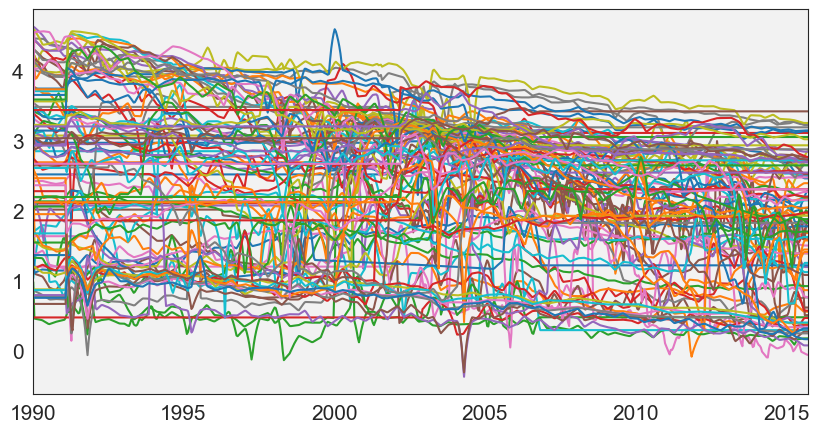

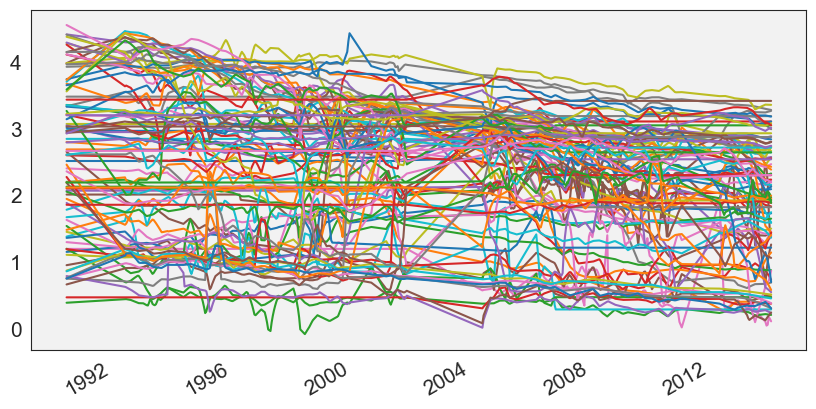

In [24]:
tritium.plot(legend=False, figsize=(10,5))
pylenm_df.remove_outliers(tritium, z_threshold=2.5).plot(legend=False, figsize=(10,5))
tritium_rm = pylenm_df.remove_outliers(tritium, z_threshold=2.5)
print(tritium.shape)
print(tritium_rm.shape)

In [22]:
pylenm_df.get_Construction_Data().head()

,FACILITY_ID,SITE_GROUP,SITE_NAME,STATION_TYPE,WELL USE,AQUIFER,WELL_USE,LATITUDE,LONGITUDE,EASTING,...,SZ_BOT(FT MSL),GROUND_ELEVATION,REFERENCE_ELEVATION_CODE,REFERENCE_ELEVATION,TOTAL_DEPTH,CONSTR_OBJ_DIAMETER,CONSTR_OBJ_MATERIAL,PUMP_TYPE,COMPLETION_DATE,DATE_SEALED
STATION_ID,,,,,,,,,,,,,,,,,,,,,
FAI001A,SRS,GSA,F & H-AREA HAZARDOUS WASTE MANAGEMENT FACILITI...,MONITORING WELL,Auxiliary Observation,UAZ_UTRAU,ACTIVE ECO-SENSITIVE,33.273872,-81.622904,441989.564,...,231.30,250.1,C,252.63,19.10,2.0,PVC,NONE,2016-03-22,NaT
FAI001B,SRS,GSA,F & H-AREA HAZARDOUS WASTE MANAGEMENT FACILITI...,MONITORING WELL,Auxiliary Observation,UAZ_UTRAU,ACTIVE ECO-SENSITIVE,33.273873,-81.622891,441990.781,...,240.60,250.2,C,252.73,9.90,2.0,PVC,NONE,2016-03-22,NaT
FAI001C,SRS,GSA,F & H-AREA HAZARDOUS WASTE MANAGEMENT FACILITI...,MONITORING WELL,Auxiliary Observation,UAZ_UTRAU,ACTIVE ECO-SENSITIVE,33.273874,-81.622895,441990.432,...,242.68,250.2,C,252.74,7.82,2.0,PVC,NONE,2016-03-22,NaT
FAI001D,SRS,GSA,F & H-AREA HAZARDOUS WASTE MANAGEMENT FACILITI...,MONITORING WELL,Auxiliary Observation,UAZ_UTRAU,ACTIVE ECO-SENSITIVE,33.273874,-81.622901,441989.928,...,246.75,250.1,C,252.56,3.65,2.0,PVC,NONE,2016-03-22,NaT
FAI002A,SRS,GSA,F & H-AREA HAZARDOUS WASTE MANAGEMENT FACILITI...,MONITORING WELL,Auxiliary Observation,UAZ_UTRAU,ACTIVE ECO-SENSITIVE,33.263961,-81.685462,436156.287,...,165.88,185.1,C,187.58,3.65,2.0,PVC,NONE,2016-03-29,NaT


## Clustering stations (wells)

['FPZ-007B', 'FPZ-006B', 'FSB-099D', 'FEX-004', 'FPZ-007A', 'FSB-087D', 'FSB-118D', 'FSB-108D', 'FSP-072A', 'FSB-089D', 'FSB-098D', 'FSP-002B', 'FPZ-006A', 'FSB-092D', 'FSB-091D', 'FSB-114D', 'FSB-109D', 'FSP-002A', 'FSB-093D', 'FSB-095DR', 'FSB-078', 'FSB-090D', 'FSB-076', 'FSB-079', 'FSP-249A', 'FSB-123D', 'FBI-014D', 'FSB-120D', 'FSB-104D', 'FSB-115D', 'FSB-094DR', 'FSB-097D', 'FSB-113D', 'FSP-072B', 'FSP-249B', 'FSB-117D', 'FPZ-002A', 'FSB-116D', 'FSB-122D', 'FSB-088D']


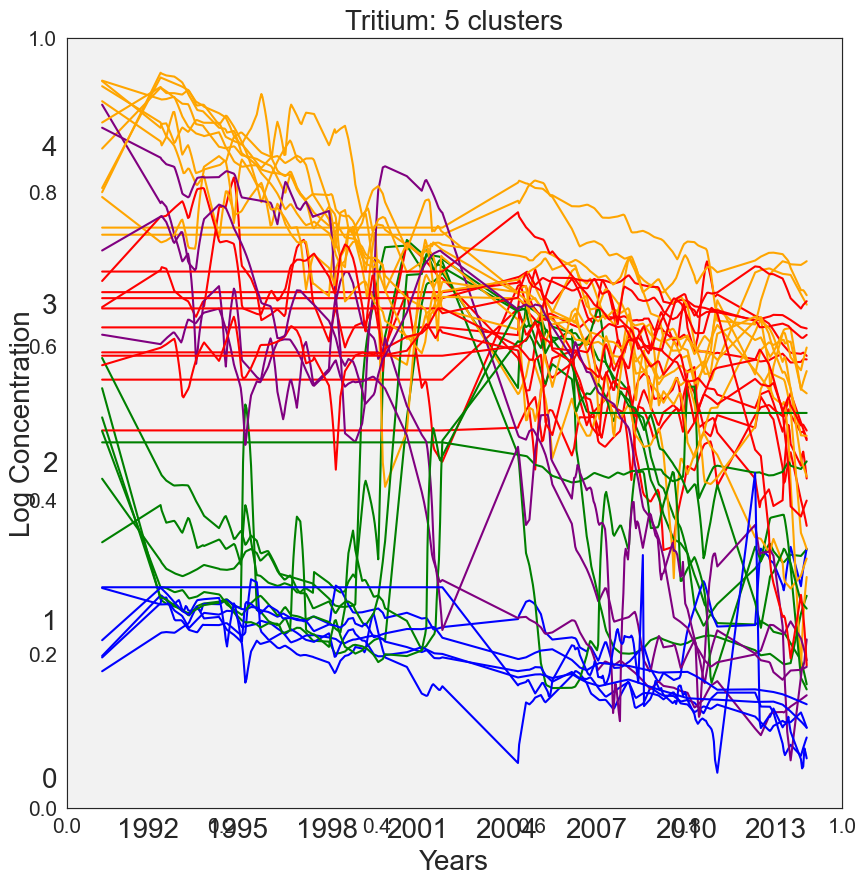

In [25]:
cluster_data = pylenm_df.cluster_data(analyte_name= 'Tritium', data = tritium_rm, n_clusters=5, year_interval=3, return_clusters=True, filter=True, col='AQUIFER', equals=['UAZ_UTRAU'], y_label = 'Log Concentration')

In [26]:
cluster_data[['STATION_ID', 'color']].head()

,STATION_ID,color
0,FBI-014D,red
1,FEX-004,red
2,FPZ-002A,blue
3,FPZ-006A,orange
4,FPZ-006B,red


## Visulaize clusters on an interactive map

In [27]:
pylenm_df.plot_coordinates_to_map(cluster_data)